
### Objetivos:

* Verificar si un bosque aleatorio o un árbol de decisión con aumento de gradiente presentan sobreajuste si
  el número de estimadores no se elige correctamente;
* Utilizar la estrategia de parada anticipada para evitar añadir árboles innecesarios, para obtener
  los mejores rendimientos de generalización.

Usamos el conjunto de datos de viviendas de California.

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

data, target = fetch_california_housing(return_X_y=True, as_frame=True)
target *= 100  # rescale the target in k$
data_train, data_test, target_train, target_test = train_test_split(
    data, target, random_state=0, test_size=0.5
)

Crea un árbol de decisión con aumento de gradiente con `max_depth=5` y `learning_rate=0.5`.


In [3]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor

# Cargar datos y dividir en conjuntos de entrenamiento y prueba
data, target = fetch_california_housing(return_X_y=True, as_frame=True)
target *= 100  # rescale the target in k$
data_train, data_test, target_train, target_test = train_test_split(
    data, target, random_state=0, test_size=0.5
)

# Crea el modelo de árbol de decisión con aumento de gradiente
modelo_gb = GradientBoostingRegressor(max_depth=5, learning_rate=0.5, random_state=0)

# Ajusta el modelo al conjunto de entrenamiento
modelo_gb.fit(data_train, target_train)

# Predice en el conjunto de prueba
predicciones = modelo_gb.predict(data_test)




---


Crea también un bosque aleatorio con árboles completamente desarrollados estableciendo `max_depth=None`.



In [4]:
from sklearn.ensemble import RandomForestRegressor

# Crea el modelo de bosque aleatorio con árboles completamente desarrollados
modelo_rf = RandomForestRegressor(max_depth=None, random_state=0, n_estimators=100)

# Ajusta el modelo al conjunto de entrenamiento
modelo_rf.fit(data_train, target_train)

# Predice en el conjunto de prueba
predicciones_rf = modelo_rf.predict(data_test)

# Evalúa el rendimiento con el error cuadrático medio
error_rf = mean_squared_error(target_test, predicciones_rf)
print(f'Error Cuadrático Medio en el conjunto de prueba (Random Forest): {error_rf}')


Error Cuadrático Medio en el conjunto de prueba (Random Forest): 2811.2910338402926


Para ambos modelos, el de aumento de gradiente y el bosque aleatorio, crea una curva de validación usando el conjunto de entrenamiento para evaluar el impacto del número de árboles en
el rendimiento de cada modelo. Evalúa la lista de parámetros `param_range = np.array([1, 2, 5, 10, 20, 50, 100])` y usa el error absoluto medio.


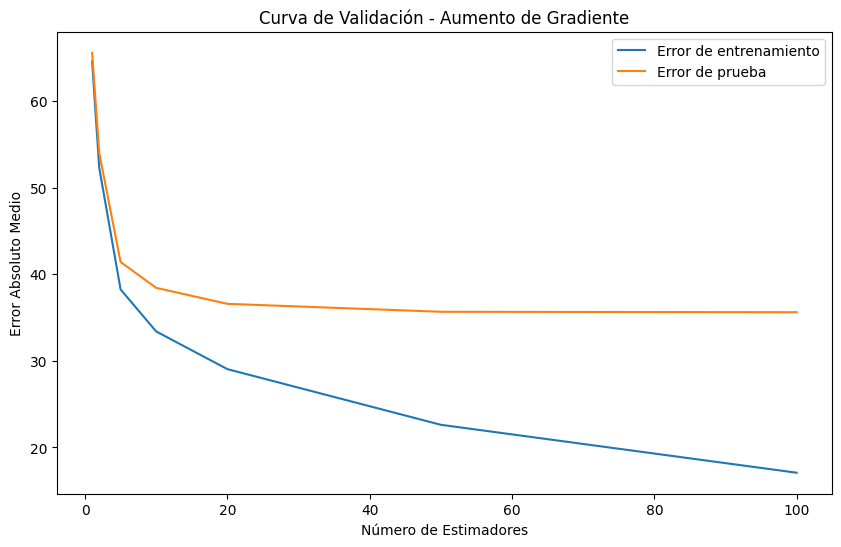

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve

# Lista de parámetros a evaluar
param_range = np.array([1, 2, 5, 10, 20, 50, 100])

# Crea el modelo de Aumento de Gradiente
modelo_gb = GradientBoostingRegressor(max_depth=5, learning_rate=0.5, random_state=0)

# Calcula la curva de validación
train_scores, test_scores = validation_curve(
    modelo_gb, data_train, target_train, param_name="n_estimators", param_range=param_range,
    scoring="neg_mean_absolute_error", n_jobs=-1, cv=5
)

# Convierte los resultados de puntuaciones a errores absolutos medios
train_errors = -train_scores.mean(axis=1)
test_errors = -test_scores.mean(axis=1)

# Grafica la curva de validación
plt.figure(figsize=(10, 6))
plt.plot(param_range, train_errors, label='Error de entrenamiento')
plt.plot(param_range, test_errors, label='Error de prueba')
plt.xlabel('Número de Estimadores')
plt.ylabel('Error Absoluto Medio')
plt.legend()
plt.title('Curva de Validación - Aumento de Gradiente')
plt.show()



Tanto los modelos de aumento de gradiente como los bosques aleatorios mejoran al aumentar el número de árboles en el conjunto. Sin embargo, las puntuaciones alcanzan un punto de saturación donde añadir nuevos árboles solo hace que el ajuste y la evaluación sean más lentos.

Para evitar añadir nuevos árboles innecesarios, a diferencia del bosque aleatorio, el aumento de gradiente ofrece una opción de parada anticipada. Internamente, el algoritmo utiliza un conjunto externo para calcular el rendimiento de generalización del modelo en cada adición de un árbol. Así, si el rendimiento de generalización no mejora durante varias iteraciones, deja de añadir árboles.

Ahora, crea un modelo de aumento de gradiente con `n_estimators=1_000`. Este número de árboles es ciertamente demasiado grande. Cambia el parámetro `n_iter_no_change` de modo que el ajuste del aumento de gradiente se detenga después de añadir 5 árboles que no mejoren el rendimiento general de generalización.


In [6]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Cargar datos y dividir en conjuntos de entrenamiento y prueba
data, target = fetch_california_housing(return_X_y=True, as_frame=True)
target *= 100  # rescale the target in k$
data_train, data_test, target_train, target_test = train_test_split(
    data, target, random_state=0, test_size=0.5
)

# Crea el modelo de aumento de gradiente con parada anticipada
modelo_gb_parada = GradientBoostingRegressor(
    max_depth=5, learning_rate=0.5, n_estimators=1000,
    n_iter_no_change=5, tol=0.001, random_state=0
)

# Ajusta el modelo al conjunto de entrenamiento
modelo_gb_parada.fit(data_train, target_train)

# Predice en el conjunto de prueba
predicciones_parada = modelo_gb_parada.predict(data_test)

# Evalúa el rendimiento con el error cuadrático medio
error_parada = mean_squared_error(target_test, predicciones_parada)
print(f'Error Cuadrático Medio en el conjunto de prueba (Parada Anticipada): {error_parada}')


Error Cuadrático Medio en el conjunto de prueba (Parada Anticipada): 2809.3988110894425


Estima el rendimiento de generalización de este modelo nuevamente utilizando la métrica `sklearn.metrics.mean_absolute_error`, pero esta vez utilizando el conjunto de prueba que reservamos al principio del ejrecicio. Compara el valor resultante con los valores observados en la curva de validación.


Error Absoluto Medio en el conjunto de prueba (Parada Anticipada): 35.46129081606355


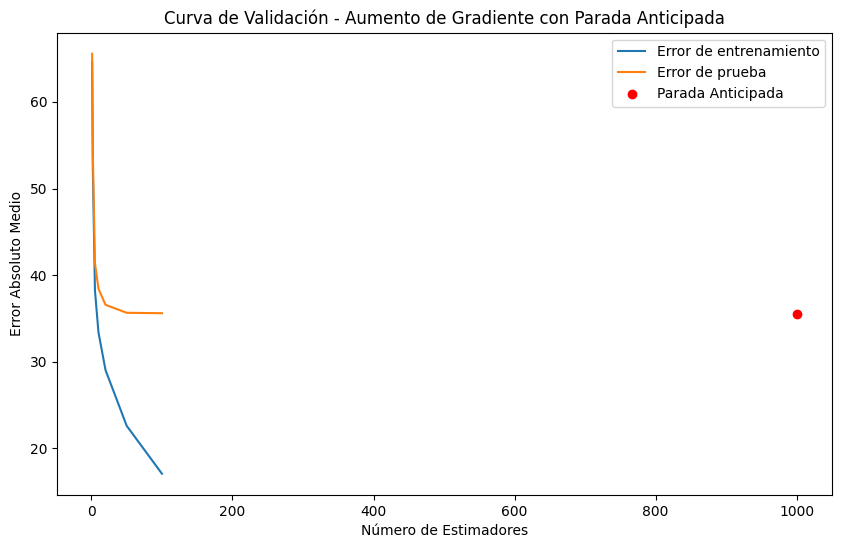

In [7]:
from sklearn.metrics import mean_absolute_error

# Predice en el conjunto de prueba
predicciones_parada = modelo_gb_parada.predict(data_test)

# Evalúa el rendimiento con el error absoluto medio
mae_parada = mean_absolute_error(target_test, predicciones_parada)
print(f'Error Absoluto Medio en el conjunto de prueba (Parada Anticipada): {mae_parada}')

# Visualiza la curva de validación para comparar
plt.figure(figsize=(10, 6))
plt.plot(param_range, train_errors, label='Error de entrenamiento')
plt.plot(param_range, test_errors, label='Error de prueba')
plt.scatter(1000, mae_parada, color='red', marker='o', label='Parada Anticipada')
plt.xlabel('Número de Estimadores')
plt.ylabel('Error Absoluto Medio')
plt.legend()
plt.title('Curva de Validación - Aumento de Gradiente con Parada Anticipada')
plt.show()
